# Saguaro Stem Count Data 2016 - 2026

## Load Data

In [10]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import scikit_posthocs as sp
from sklearn.linear_model import LinearRegression

In [11]:
# load bud count csv
df = pd.read_csv('Saguaro Bud Counts - Stem Counts.csv')
df = df.drop(columns=['Unnamed: 3'])
df.head()

,Image,Year,Stem Count
0,15,2016,1
1,18,2016,9
2,19,2016,6
3,20,2016,3
4,21,2016,1


## Graph Data

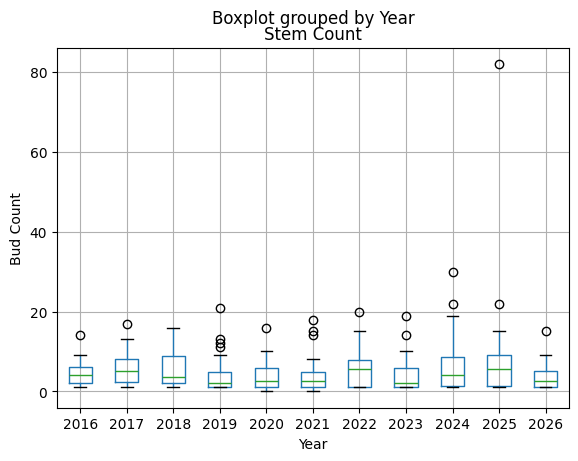

In [12]:
# box plot by year
df.boxplot(column='Stem Count', by='Year')

plt.xlabel("Year")
plt.ylabel("Bud Count")
plt.show()

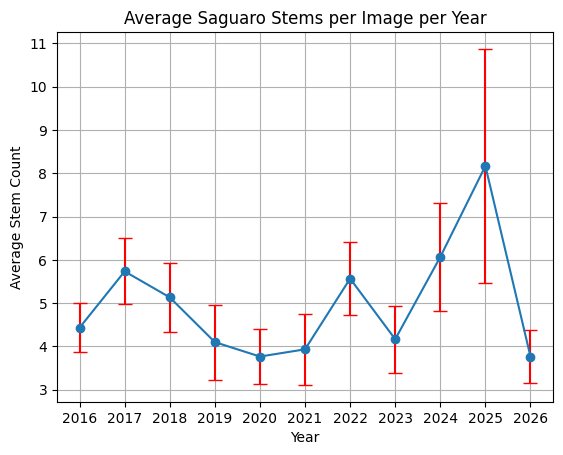

In [13]:
# line plot for mean each year with standard errors
yearly_stems_mean = df.groupby('Year')['Stem Count'].mean()
yearly_stems_se = df.groupby('Year')['Stem Count'].sem()

plt.errorbar(yearly_stems_mean.index, yearly_stems_mean.values, yerr=yearly_stems_se.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Stem Count")
plt.title("Average Saguaro Stems per Image per Year")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

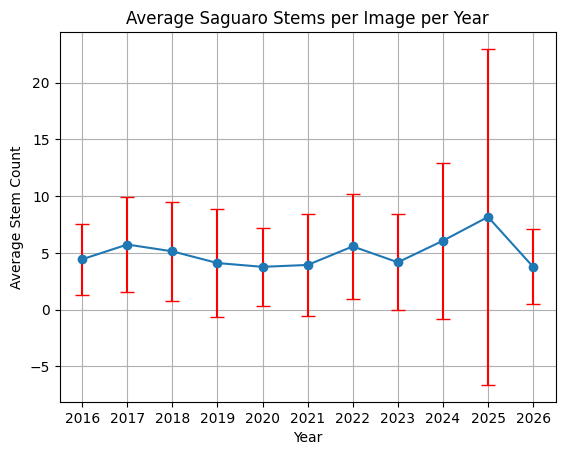

In [14]:
# line plot for mean each year with standard deviation
yearly_stems_std = df.groupby('Year')['Stem Count'].std()

plt.errorbar(yearly_stems_mean.index, yearly_stems_mean.values, yerr=yearly_stems_std.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Stem Count")
plt.title("Average Saguaro Stems per Image per Year")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

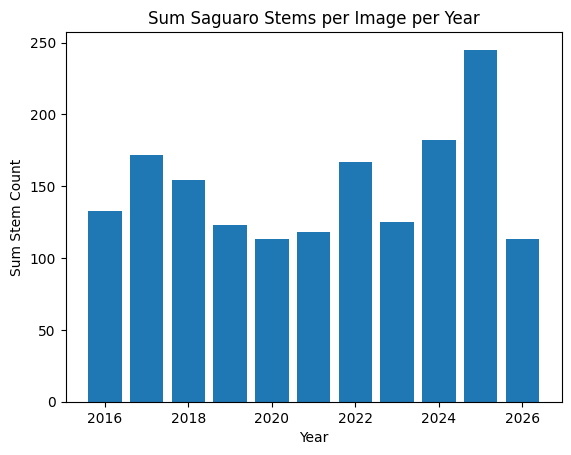

In [15]:
# bar plot for sums each year
yearly_stems_sum = df.groupby('Year')['Stem Count'].sum()

plt.bar(yearly_stems_sum.index, yearly_stems_sum.values)

plt.xlabel("Year")
plt.ylabel("Sum Stem Count")
plt.title("Sum Saguaro Stems per Image per Year")
plt.show()

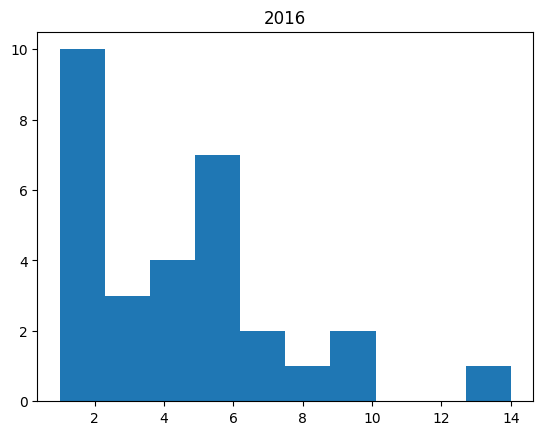

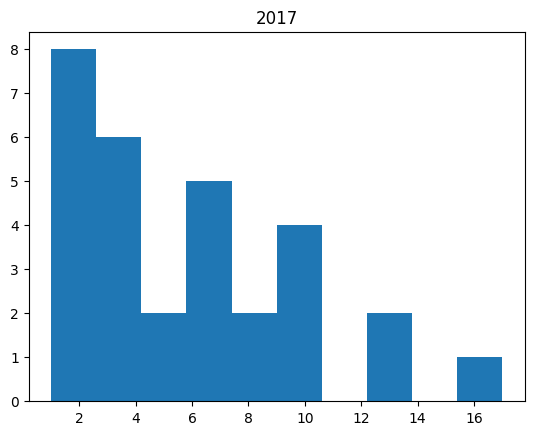

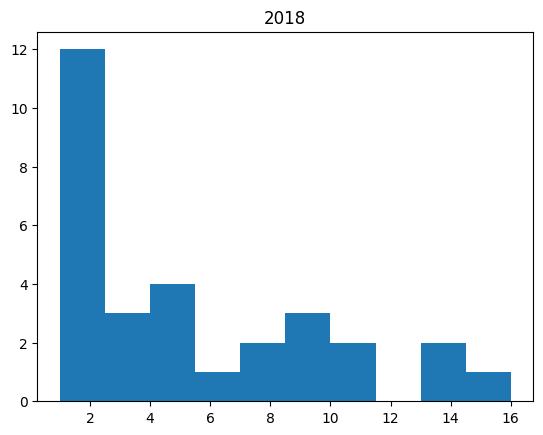

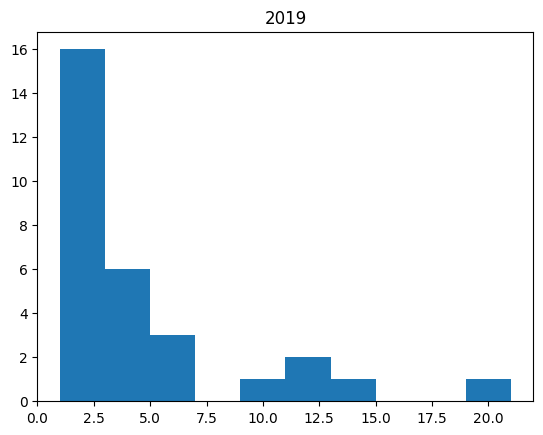

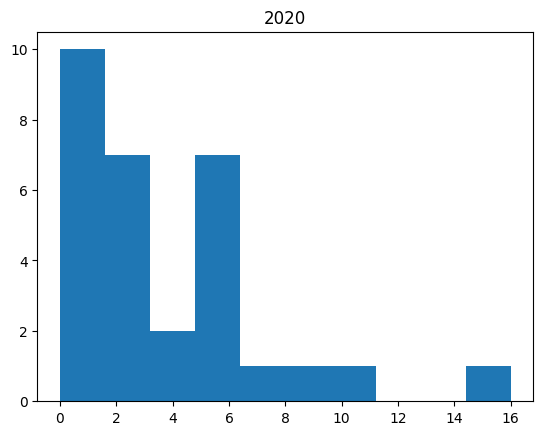

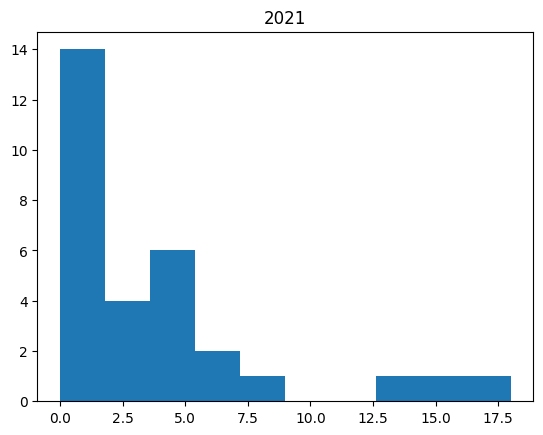

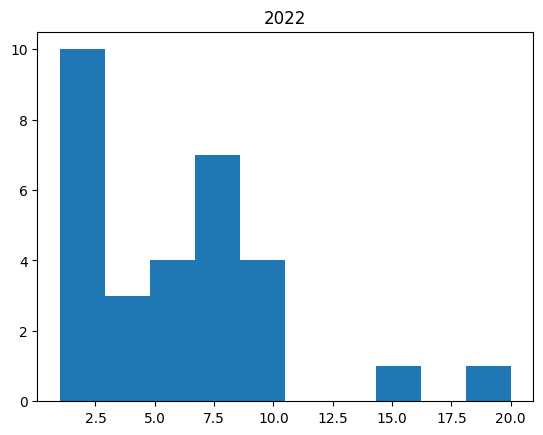

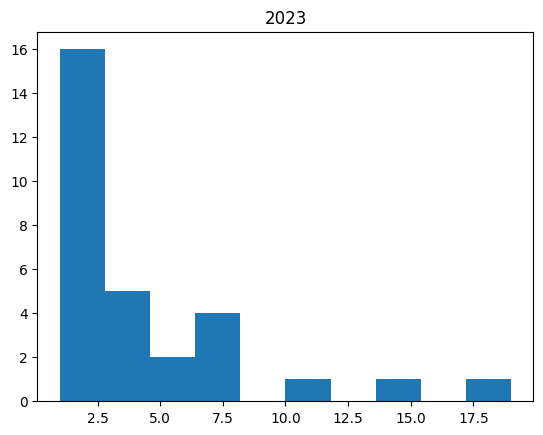

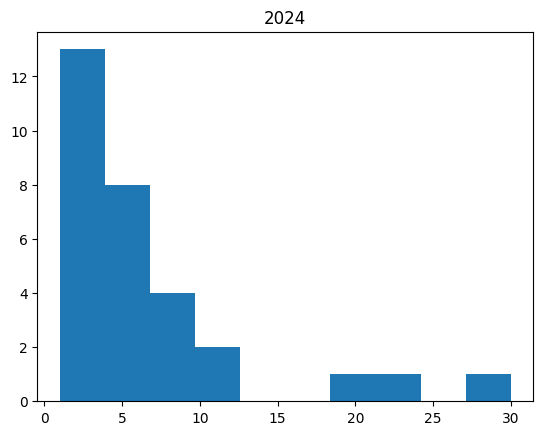

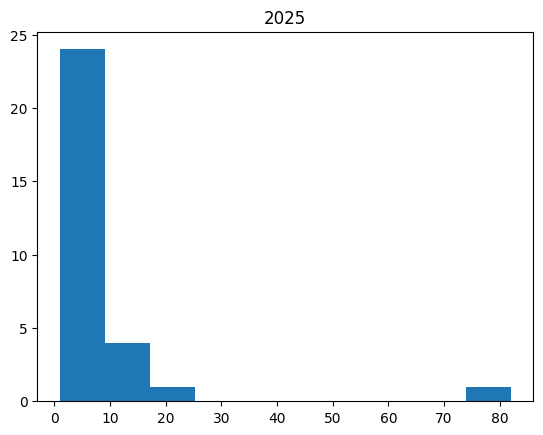

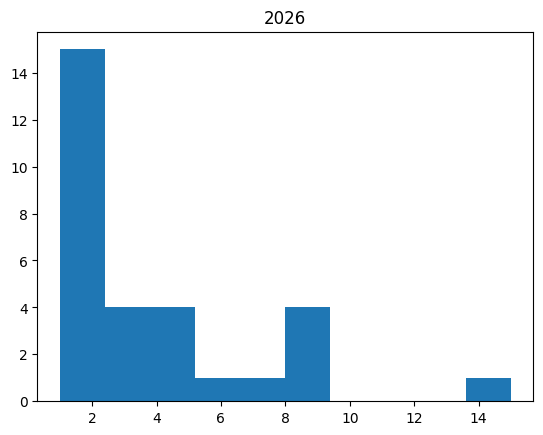

In [16]:
# make a histogram of each year 
for i in df.Year.unique():
    plt.hist(df[df['Year'] == i]['Stem Count'])
    plt.title(i)
    plt.show()

## Statistical Analysis

In [17]:
# check if anova test is valid
# check normality
model = LinearRegression()
model.fit(df[['Year']], df[['Stem Count']])

predictions = model.predict(df[['Year']])
residuals = df[['Stem Count']] - predictions

stat, p = stats.shapiro(residuals)
print("Shapiro-Wilk p-value:", p)

# check homogeneity of variances
stems_2016 = df.loc[df['Year'] == 2016, 'Stem Count']
stems_2017 = df.loc[df['Year'] == 2017, 'Stem Count']
stems_2018 = df.loc[df['Year'] == 2018, 'Stem Count']
stems_2019 = df.loc[df['Year'] == 2019, 'Stem Count']
stems_2020 = df.loc[df['Year'] == 2020, 'Stem Count']
stems_2021 = df.loc[df['Year'] == 2021, 'Stem Count']
stems_2022 = df.loc[df['Year'] == 2022, 'Stem Count']
stems_2023 = df.loc[df['Year'] == 2023, 'Stem Count']
stems_2024 = df.loc[df['Year'] == 2024, 'Stem Count']
stems_2025 = df.loc[df['Year'] == 2025, 'Stem Count']
stems_2026 = df.loc[df['Year'] == 2026, 'Stem Count']
data = [stems_2016, stems_2017, stems_2018, stems_2019, stems_2020, stems_2021, stems_2022, stems_2023, stems_2024, stems_2025, stems_2026]

stat1, p1 = stats.levene(stems_2016, stems_2017, stems_2018, stems_2019, stems_2020, stems_2021, stems_2022, stems_2023, stems_2024, stems_2025, stems_2026)
print("Levene's p-value:", p1)

Shapiro-Wilk p-value: 2.221068005497154e-27
Levene's p-value: 0.21616150367555514


Since the Shapiro Wilk p-value is less than 0.05, the data is not normally distributed. On the other hand, since the Levene's p-value is greater than 0.05 the data has homogeneity of variances meaning that we can use a parametric test on the data. 

In [18]:
# continue with anova 
f_stat, p2 = stats.f_oneway(stems_2016, stems_2017, stems_2018, stems_2019, stems_2020, stems_2021, stems_2022, stems_2023, stems_2024, stems_2025, stems_2026)
print("f-statistic:", f_stat)
print("p-value:", p2)

f-statistic: 1.4272665412259944
p-value: 0.16685658094659903


Since the p-value is greater than 0.05, this means that there is not a significant difference between the means of stems in each image each year.

## Remove Outliers

In [19]:
# get outliers
clean_data = []

for year in df['Year'].unique():
    year_data = df[df['Year'] == year]

    Q1 = year_data['Stem Count'].quantile(0.25)
    Q3 = year_data['Stem Count'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    clean_year = year_data[
        (year_data['Stem Count'] >= lower) &
        (year_data['Stem Count'] <= upper)
    ]

    clean_data.append(clean_year)

df_no_outliers = pd.concat(clean_data)

In [20]:
df_no_outliers.info()

<class 'pandas.DataFrame'>
Index: 312 entries, 0 to 329
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Image       312 non-null    int64
 1   Year        312 non-null    int64
 2   Stem Count  312 non-null    int64
dtypes: int64(3)
memory usage: 9.8 KB


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Image       330 non-null    int64
 1   Year        330 non-null    int64
 2   Stem Count  330 non-null    int64
dtypes: int64(3)
memory usage: 7.9 KB


18 outliers removed

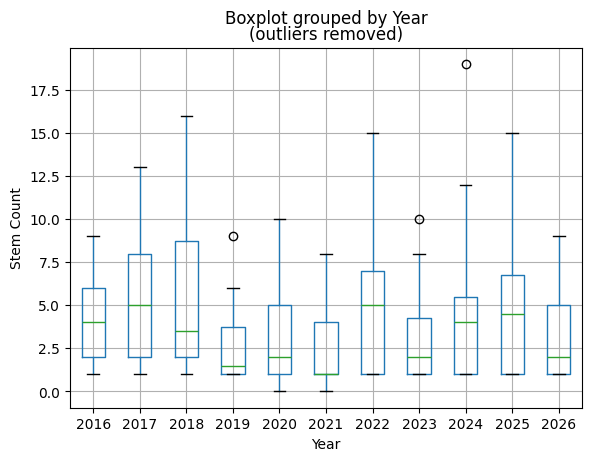

In [14]:
df_no_outliers.boxplot(column='Stem Count', by='Year')

plt.xlabel("Year")
plt.ylabel("Stem Count")
plt.title("(outliers removed)")
plt.show()

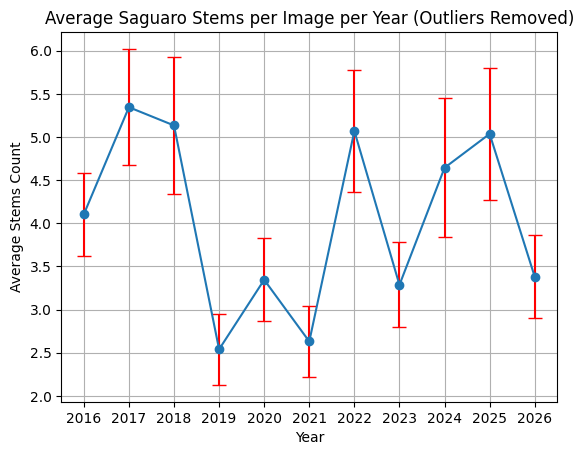

In [22]:
# line plot for mean each year with standard errors
yearly_stems_mean1 = df_no_outliers.groupby('Year')['Stem Count'].mean()
yearly_stems_se1 = df_no_outliers.groupby('Year')['Stem Count'].sem()

plt.errorbar(yearly_stems_mean1.index, yearly_stems_mean1.values, yerr=yearly_stems_se1.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Stems Count")
plt.title("Average Saguaro Stems per Image per Year (Outliers Removed)")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

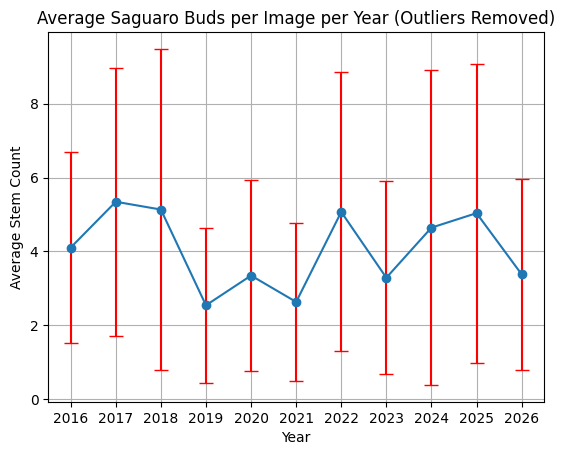

In [24]:
# line plot for mean each year with standard deviation
yearly_stems_std1 = df_no_outliers.groupby('Year')['Stem Count'].std()

plt.errorbar(yearly_stems_mean1.index, yearly_stems_mean1.values, yerr=yearly_stems_std1.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Stem Count")
plt.title("Average Saguaro Buds per Image per Year (Outliers Removed)")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

In [25]:
# check if anova test is valid
# check normality
model1 = LinearRegression()
model1.fit(df_no_outliers[['Year']], df_no_outliers[['Stem Count']])

predictions1 = model1.predict(df_no_outliers[['Year']])
residuals1 = df_no_outliers[['Stem Count']] - predictions1

stat2, p3 = stats.shapiro(residuals1)
print("Shapiro-Wilk p-value:", p3)

# check homogeneity of variances
ostems_2016 = df_no_outliers.loc[df['Year'] == 2016, 'Stem Count']
ostems_2017 = df_no_outliers.loc[df['Year'] == 2017, 'Stem Count']
ostems_2018 = df_no_outliers.loc[df['Year'] == 2018, 'Stem Count']
ostems_2019 = df_no_outliers.loc[df['Year'] == 2019, 'Stem Count']
ostems_2020 = df_no_outliers.loc[df['Year'] == 2020, 'Stem Count']
ostems_2021 = df_no_outliers.loc[df['Year'] == 2021, 'Stem Count']
ostems_2022 = df_no_outliers.loc[df['Year'] == 2022, 'Stem Count']
ostems_2023 = df_no_outliers.loc[df['Year'] == 2023, 'Stem Count']
ostems_2024 = df_no_outliers.loc[df['Year'] == 2024, 'Stem Count']
ostems_2025 = df_no_outliers.loc[df['Year'] == 2025, 'Stem Count']
ostems_2026 = df_no_outliers.loc[df['Year'] == 2026, 'Stem Count']
data1 = [ostems_2016, ostems_2017, ostems_2018, ostems_2019, ostems_2020, ostems_2021, ostems_2022, ostems_2023, ostems_2024, ostems_2025, ostems_2026]

stat3, p4 = stats.levene(ostems_2016, ostems_2017, ostems_2018, ostems_2019, ostems_2020, ostems_2021, ostems_2022, ostems_2023, ostems_2024, ostems_2025, ostems_2026)
print("Levene's p-value:", p4)

Shapiro-Wilk p-value: 6.41059794268287e-16
Levene's p-value: 0.0031663564045346974


The Shapiro-Wilk p-value is less than 0.05 meaning that the data is not normally distributed. The Levene's p-value is also less than 0.05 meaning that the data does not have homogeneity of variences. Since the data is neither normally distributed nor has homogeneity of variences, a non parametric test must be done.

In [26]:
# do anova test on all years without outliers
h_stat1, p_val1 = stats.kruskal(ostems_2016, ostems_2017, ostems_2018, ostems_2019, ostems_2020, ostems_2021, ostems_2022, ostems_2023, ostems_2024, ostems_2025, ostems_2026)

print("h-statistic:", h_stat1)
print("p-value:", p_val1)

h-statistic: 22.90303060027538
p-value: 0.011110223264667731


Since the p-value is less than 0.05, there is a significant difference between at least some of the means of stems each year. A non parametric pairwise comparison test will be done to see the differences between each year.

In [27]:
# dunn test on data without outliers
dunn_results1 = sp.posthoc_dunn(data1, p_adjust='bonferroni')
dunn_results1.columns = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
dunn_results1.index =  ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
dunn_results1

,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
2016,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000,1.0
2017,1.0,1.000000,1.000000,0.093330,1.0,0.104357,1.000000,1.0,1.0,1.000000,1.0
2018,1.0,1.000000,1.000000,0.538702,1.0,0.601869,1.000000,1.0,1.0,1.000000,1.0
2019,1.0,0.093330,0.538702,1.000000,1.0,1.000000,0.473369,1.0,1.0,0.673010,1.0
2020,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000,1.0
2021,1.0,0.104357,0.601869,1.000000,1.0,1.000000,0.528865,1.0,1.0,0.751009,1.0
2022,1.0,1.000000,1.000000,0.473369,1.0,0.528865,1.000000,1.0,1.0,1.000000,1.0
2023,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000,1.0
2024,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000,1.0
2025,1.0,1.000000,1.000000,0.673010,1.0,0.751009,1.000000,1.0,1.0,1.000000,1.0


It seems that none of them are less than 0.05?